# Stocktaking AI — Demo trực quan hoá Pipeline

Notebook này chạy **`InventoryPipeline.run_with_trace()`** trên một ảnh kệ hàng bất kỳ trong `data/query/`
và hiển thị trực quan **từng giai đoạn** của pipeline:

1. Detection (RF-DETR) — vẽ bounding box
2. Overlap Analysis — nhóm các detection nghi ngờ chồng lấp
3. Segmentation Refinement (SAM2) — so sánh bbox gốc vs bbox đã refine
4. Cropping — resized crop (retrieval) vs raw crop (plugin)
5. Visual Retrieval (SigLIP2 + FAISS) — ảnh query vs Top-K gallery + similarity
6. Decision Engine — bảng quyết định, ngưỡng, cờ kích hoạt plugin
7. Plugin Evidence — kết quả chi tiết OCR / Color / Barcode
8. Reranking & Fusion — so sánh ranking **trước và sau** khi hợp nhất bằng chứng
9. E2E Summary — ảnh annotate cuối cùng + thống kê số lượng theo SKU

> **Lưu ý:** notebook này cần chạy trên máy có đủ `weights/`, `data/gallery/`, `data/cache/gallery_index.faiss`
> và GPU (hoặc CPU, chậm hơn). Nó **không** sửa đổi pipeline production — chỉ gọi API công khai
> (`load_config`, `InventoryPipeline.run_with_trace`) giống hệt cách VAL/CLI sử dụng.

## 1. Import & khởi tạo project

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import json
from pathlib import Path
from collections import Counter
from IPython.display import display
import unicodedata

%matplotlib inline
pd.set_option("display.max_colwidth", 60)

In [34]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
while not (PROJECT_ROOT / "configs" / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Không tìm thấy configs/config.yaml. Hãy chạy notebook này từ bên trong "
            "thư mục project (hoặc đặt PROJECT_ROOT thủ công ở đây)."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [35]:
from src.core.config import load_config
from src.models.models import BoundingBox, ImageData
from src.pipeline.pipeline import InventoryPipeline

config = load_config()
print(f"App: {config.app.name} v{config.app.version} | device={config.app.device}")
print(f"Detection backend: {config.detection.backend}")
print(f"Retrieval backend: {config.retrieval.backend}")
print(f"Refinement backend: {config.refinement.backend}")

pipeline = InventoryPipeline(config)
print("\nPipeline đã khởi tạo xong (đã load model weights).")

App: Stocktaking AI v0.1.0 | device=cuda
Detection backend: rf_detr
Retrieval backend: siglip2
Refinement backend: sam2
2026-09-04 02:45:51 | INFO     | src.detection.backends.rf_detr | Loading RF-DETR model class='RFDETRBase' kwargs={'pretrain_weights': 'weights/detector/checkpoint_best_ema.pth'}


[2026-09-04 02:45:52] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-04 02:45:52] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


2026-09-04 02:45:52 | INFO     | src.detection.backends.rf_detr | Optimizing RF-DETR for inference (dtype=float32 compile=False batch_size=1)
2026-09-04 02:45:53 | INFO     | src.detection.backends.rf_detr | RfDetrBackend initialized (variant='base' weights_path='weights/detector/checkpoint_best_ema.pth')
2026-09-04 02:45:53 | INFO     | src.detection.detector | Detector initialized with backend='rf_detr'
2026-09-04 02:45:53 | INFO     | src.pipeline.overlap | OverlapResolver initialized (enabled=True iou_threshold=0.050 overlap_ratio_threshold=0.200 min_overlapping_pairs=1 require_multiple_detections=True)
2026-09-04 02:45:53 | INFO     | src.segmentation.backends.sam2 | SAM2 checkpoint found locally: 'weights\refinement\sam2\sam2.1_hiera_small.pt'
2026-09-04 02:45:53 | INFO     | src.segmentation.backends.sam2 | Loading SAM2 model_config='configs/sam2.1/sam2.1_hiera_s.yaml' checkpoint='weights\refinement\sam2\sam2.1_hiera_small.pt' device='cuda'
2026-09-04 02:45:53 | INFO     | src.s

Loading weights: 100%|██████████| 408/408 [00:04<00:00, 101.62it/s]


2026-09-04 02:46:05 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 CUDA memory after load: allocated=2.65 GB reserved=3.40 GB
2026-09-04 02:46:05 | INFO     | src.retrieval.backends.siglip2 | Siglip2Backend initialized (model_name='google/siglip2-base-patch16-224', device='cuda', dtype='torch.float16')
2026-09-04 02:46:05 | INFO     | src.retrieval.retriever | Loading gallery FAISS index from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_index.faiss'.
2026-09-04 02:46:05 | INFO     | src.retrieval.retriever | Loading gallery metadata from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\cache\gallery_metadata.json'.
2026-09-04 02:46:05 | INFO     | src.retrieval.retriever | Loading product catalog from 'G:\VsCode\Python\DACN\stocktaking_ai_mini\data\metadata\products.json'.
2026-09-04 02:46:05 | INFO     | src.retrieval.retriever | Loaded 21 product(s) from catalog.
2026-09-04 02:46:05 | INFO     | src.retrieval.retriever | Retriever initialized with backend='sigl

## 2. Hàm tiện ích hiển thị

In [36]:
def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_image(img_bgr, title="", figsize=(10, 8), ax=None):
    rgb = bgr2rgb(img_bgr)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    return ax

def show_images_row(images, titles=None, figsize_per_img=(4, 4)):
    n = len(images)
    if n == 0:
        print("(không có ảnh để hiển thị)")
        return
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_img[0] * n, figsize_per_img[1]))
    if n == 1:
        axes = [axes]
    for i, img in enumerate(images):
        title = titles[i] if titles else ""
        show_image(img, title=title, ax=axes[i])
        axes[i].set_title(title, fontsize=9, wrap=True, pad=10)
        
    plt.tight_layout()
    plt.show()

STATUS_COLORS_BGR = {
    "accepted": (0, 200, 0),
    "uncertain": (0, 165, 255),
    "rejected": (0, 0, 220),
}

def draw_detections(image, boxes, labels=None, colors=None, thickness=3, font_scale=0.6):
    out = image.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(v) for v in box.as_list()]
        color = colors[i] if colors else (0, 200, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if labels:
            label = str(labels[i])
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 2)
            cv2.rectangle(out, (x1, max(0, y1 - th - 8)), (x1 + tw + 6, y1), color, -1)
            cv2.putText(out, label, (x1 + 3, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX,
                        font_scale, (255, 255, 255), 2)
    return out

def hex_to_bgr(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return (b, g, r)

def show_color_palette(hex_colors, percentages, title=""):
    fig, ax = plt.subplots(figsize=(6, 1.4))
    x = 0.0
    for hex_c, pct in zip(hex_colors, percentages):
        ax.add_patch(mpatches.Rectangle((x, 0), max(pct, 0.02), 1, color=hex_c))
        ax.text(x + max(pct, 0.02) / 2, 0.5, f"{pct:.0%}", ha="center", va="center",
                fontsize=8, color="white" if pct > 0.08 else "black")
        x += pct
    ax.set_xlim(0, max(x, 1.0))
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. Chọn & nạp ảnh query

Tìm thấy 13 ảnh trong G:\VsCode\Python\DACN\stocktaking_ai_mini\data\query
-> Chọn ảnh theo đường dẫn tùy chỉnh thành công!

[OK] Ảnh được sử dụng: g:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark\images\3_jpg.rf.ZbJrojyWq6VoaQRpgI1u.jpg


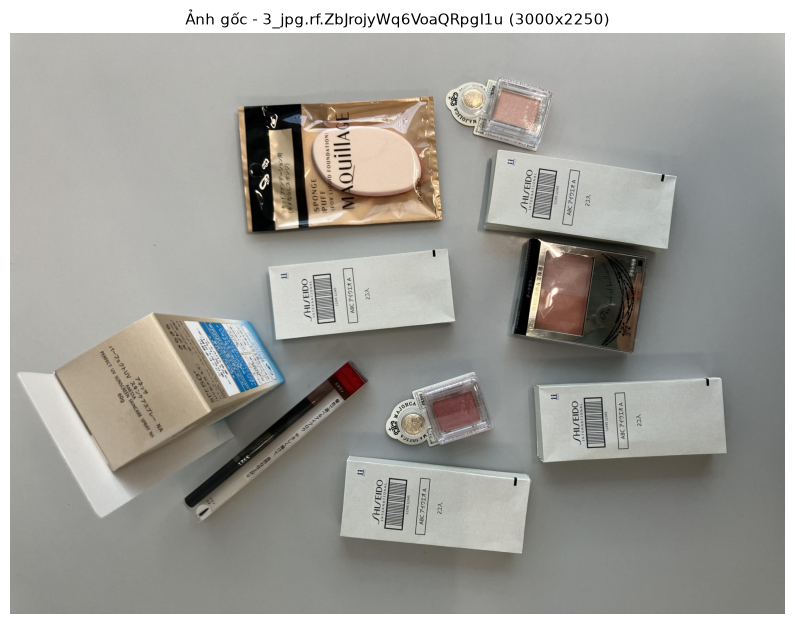

In [37]:

query_dir = config.resolve_path(config.paths.query_dir)
candidate_images = sorted(
    list(query_dir.glob("*.jpg")) + list(query_dir.glob("*.png")) + list(query_dir.glob("*.jpeg"))
)
print(f"Tìm thấy {len(candidate_images)} ảnh trong {query_dir}")

# =====================================================================
# 1. NHẬP ĐƯỜNG DẪN ẢNH BẠN MUỐN CHỌN Ở ĐÂY
# =====================================================================
CUSTOM_PATH = PROJECT_ROOT / "data" / "benchmark" / "images" / "3_jpg.rf.ZbJrojyWq6VoaQRpgI1u.jpg"  # Thay tên ảnh của bạn vào đây

# Convert sang kiểu Path
custom_image_path = PROJECT_ROOT / CUSTOM_PATH if isinstance(CUSTOM_PATH, str) and CUSTOM_PATH else CUSTOM_PATH

# 2. KIỂM TRA VÀ CHỌN ẢNH (FALLBACK NẾU LỖI)
if custom_image_path and custom_image_path.exists():
    QUERY_IMAGE_PATH = custom_image_path
    print(f"-> Chọn ảnh theo đường dẫn tùy chỉnh thành công!")
else:
    if CUSTOM_PATH:
        print(f"⚠️ CẢNH BÁO: Không tìm thấy ảnh tại '{CUSTOM_PATH}'.")
    
    if candidate_images:
        QUERY_IMAGE_PATH = candidate_images[0]
        print(f"-> Tự động chuyển về chọn ảnh đầu tiên trong thư mục: {QUERY_IMAGE_PATH.name}")
    else:
        QUERY_IMAGE_PATH = None

# 3. KIỂM TRA BẮT BUỘC VÀ ĐỌC ẢNH
assert QUERY_IMAGE_PATH is not None, (
    "Không tìm thấy ảnh nào! Hãy kiểm tra lại đường dẫn nhập vào "
    "hoặc đặt ít nhất 1 ảnh vào thư mục data/query/."
)

print(f"\n[OK] Ảnh được sử dụng: {QUERY_IMAGE_PATH}")

raw_bgr = cv2.imread(str(QUERY_IMAGE_PATH))
assert raw_bgr is not None, f"Lỗi: File tồn tại nhưng OpenCV không thể đọc được ảnh tại {QUERY_IMAGE_PATH}"
h, w = raw_bgr.shape[:2]

image_data = ImageData(
    image_id=QUERY_IMAGE_PATH.stem,
    source_path=str(QUERY_IMAGE_PATH),
    image_array=raw_bgr,
    width=w,
    height=h,
)

show_image(raw_bgr, title=f"Ảnh gốc - {image_data.image_id} ({w}x{h})", figsize=(10, 8))
plt.show()

## 4. Chạy pipeline đầy đủ (`run_with_trace`)

In [38]:
result, trace = pipeline.run_with_trace(image_data)

print(f"Pipeline hoàn tất trong {result.processing_time_ms:.1f} ms")
print(f"Số sản phẩm được chấp nhận (accepted): {result.total_items}")
print(f"Tổng số detection ban đầu: {len(trace.detection_result.detections)}")
print(f"Tổng số crop được xử lý: {len(trace.crops)}")

detections = trace.detection_result.detections
crop_traces = trace.crops

2026-09-04 02:46:09 | INFO     | src.detection.detector | Detector found 10 region(s) in image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (311.47 ms)
2026-09-04 02:46:09 | INFO     | src.pipeline.overlap | OverlapResolver flagged 2 suspicious pair(s) forming 2 group(s) for image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (0.16 ms)
2026-09-04 02:46:10 | INFO     | src.segmentation.refiner | Refiner processed 4 detection(s) for image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (1477.41 ms)
2026-09-04 02:46:10 | INFO     | src.detection.cropper | Cropper produced 10 crop(s) for image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (9.15 ms)
2026-09-04 02:46:10 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 input: shape=(1, 3, 224, 224) dtype=torch.float32
2026-09-04 02:46:10 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 device input: shape=(1, 3, 224, 224) dtype=torch.float32 device=cuda:0
2026-09-04 02:46:10 | INFO     | src.retrieval.backends.siglip2 | SigLIP2 raw output type=<class 'transformers.modeling_out

## ① Detection — Bounding box (RF-DETR)

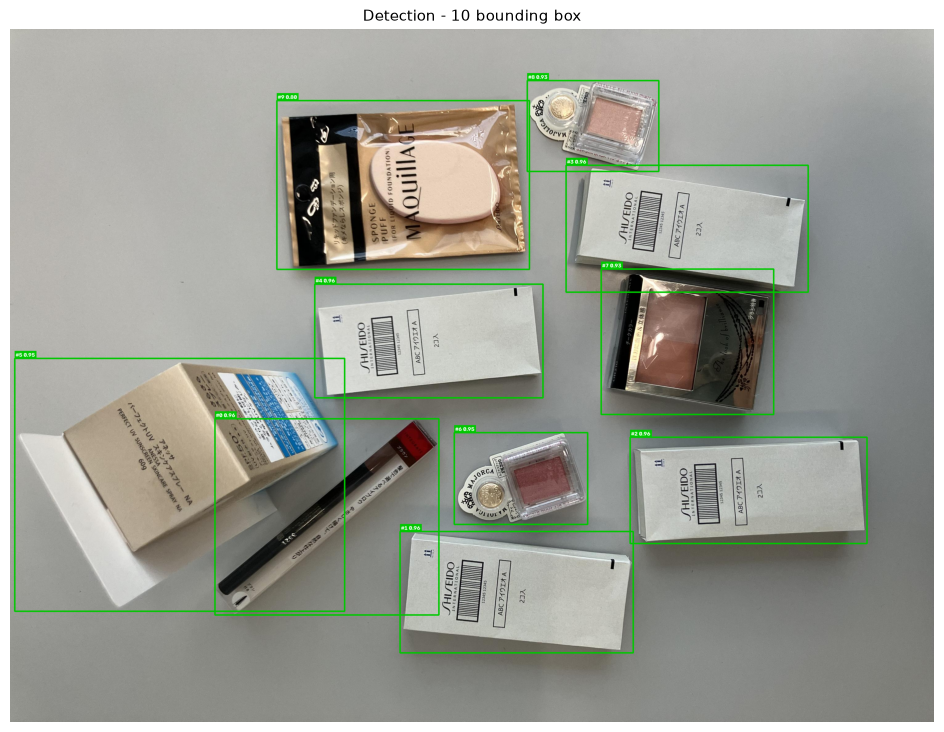

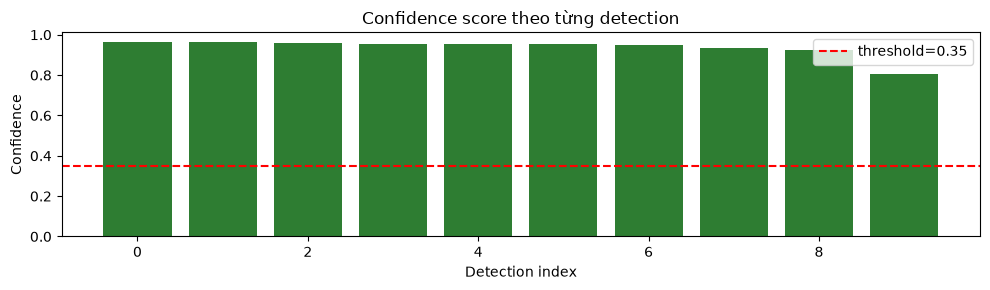

In [39]:
boxes = [d.bbox for d in detections]
labels = [f"#{i} {d.confidence:.2f}" for i, d in enumerate(detections)]

detection_vis = draw_detections(raw_bgr, boxes, labels=labels, thickness=3, font_scale=0.6)
show_image(detection_vis, title=f"Detection - {len(detections)} bounding box", figsize=(12, 9))
plt.show()

conf_scores = [d.confidence for d in detections]
plt.figure(figsize=(10, 3))
plt.bar(range(len(conf_scores)), conf_scores, color="#2e7d32")
plt.axhline(config.detection.confidence_threshold, color="red", linestyle="--",
            label=f"threshold={config.detection.confidence_threshold}")
plt.xlabel("Detection index")
plt.ylabel("Confidence")
plt.title("Confidence score theo từng detection")
plt.legend()
plt.tight_layout()
plt.show()

## ② Overlap Analysis

needs_refinement = True
Số overlap group: 2 | Số detection liên quan: 4


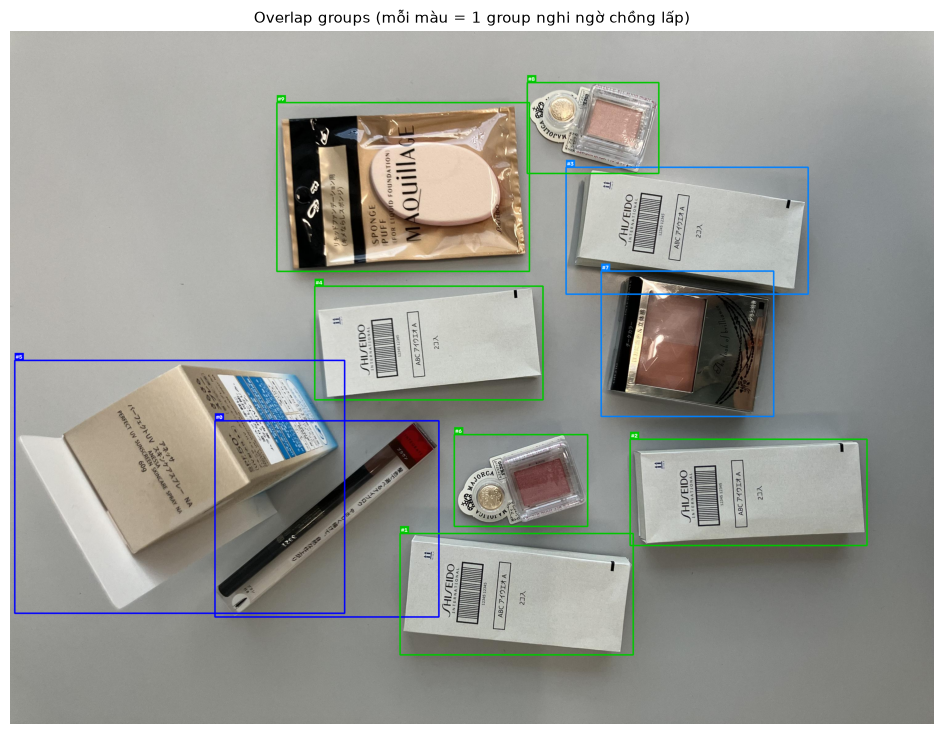

,group_id,det_a,det_b,iou,intersection_ratio_a,intersection_ratio_b,containment
0,0,0,5,0.243,0.568,0.299,False
1,1,3,7,0.076,0.129,0.158,False


In [40]:
overlap = trace.overlap_result
print(f"needs_refinement = {overlap.needs_refinement}")
print(f"Số overlap group: {overlap.group_count} | Số detection liên quan: {overlap.overlapping_detection_count}")

if overlap.groups:
    colors_cycle = [(255, 0, 0), (255, 128, 0), (255, 0, 255), (0, 255, 255), (128, 0, 255)]
    box_colors = [(0, 200, 0)] * len(detections)
    for gi, group in enumerate(overlap.groups):
        c = colors_cycle[gi % len(colors_cycle)]
        for idx in group.detection_indices:
            box_colors[idx] = c

    labels_overlap = [f"#{i}" for i in range(len(detections))]
    overlap_vis = draw_detections(raw_bgr, boxes, labels=labels_overlap, colors=box_colors,
                                   thickness=3, font_scale=0.6)
    show_image(overlap_vis, title="Overlap groups (mỗi màu = 1 group nghi ngờ chồng lấp)",
               figsize=(12, 9))
    plt.show()

    rows = []
    for group in overlap.groups:
        for pair in group.pairs:
            rows.append({
                "group_id": group.group_id,
                "det_a": pair.detection_index_a,
                "det_b": pair.detection_index_b,
                "iou": round(pair.iou, 3),
                "intersection_ratio_a": round(pair.intersection_ratio_a, 3),
                "intersection_ratio_b": round(pair.intersection_ratio_b, 3),
                "containment": pair.is_containment,
            })
    display(pd.DataFrame(rows))
else:
    print("Không có overlap group nào -> SAM2 refinement không được kích hoạt cho ảnh này.")

## ③ Segmentation Refinement (SAM2)

triggered = True | backend = sam2
Số box được refine: 4


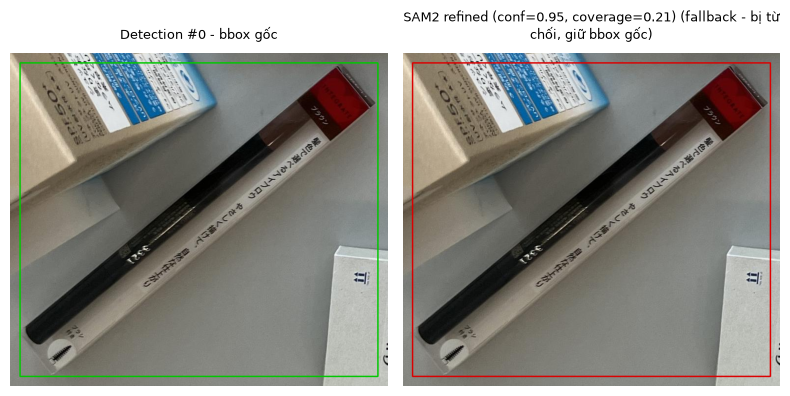

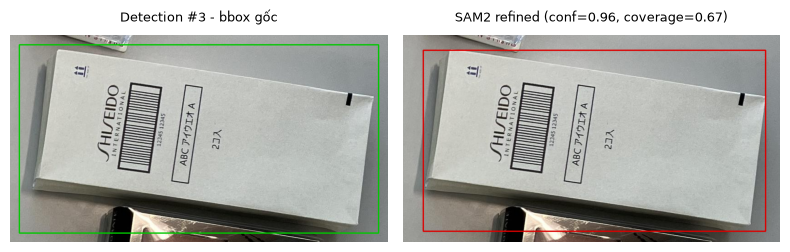

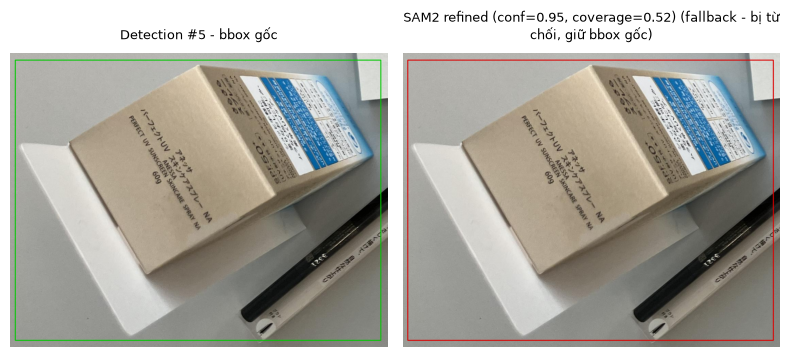

In [41]:
refinement = trace.refinement_result
print(f"triggered = {refinement.triggered} | backend = {refinement.backend}")
print(f"Số box được refine: {len(refinement.refined_boxes)}")

if refinement.refined_boxes:
    n_show = min(3, len(refinement.refined_boxes))
    for rb in refinement.refined_boxes[:n_show]:
        det_idx = rb.detection_index
        original_box = detections[det_idx].bbox
        pad = 20
        x1 = int(max(0, min(original_box.x1, rb.refined_bbox.x1) - pad))
        y1 = int(max(0, min(original_box.y1, rb.refined_bbox.y1) - pad))
        x2 = int(min(w, max(original_box.x2, rb.refined_bbox.x2) + pad))
        y2 = int(min(h, max(original_box.y2, rb.refined_bbox.y2) + pad))

        region = raw_bgr[y1:y2, x1:x2].copy()

        before = region.copy()
        ox1, oy1 = int(original_box.x1 - x1), int(original_box.y1 - y1)
        ox2, oy2 = int(original_box.x2 - x1), int(original_box.y2 - y1)
        cv2.rectangle(before, (ox1, oy1), (ox2, oy2), (0, 200, 0), 2)

        after = region.copy()
        rx1, ry1 = int(rb.refined_bbox.x1 - x1), int(rb.refined_bbox.y1 - y1)
        rx2, ry2 = int(rb.refined_bbox.x2 - x1), int(rb.refined_bbox.y2 - y1)
        cv2.rectangle(after, (rx1, ry1), (rx2, ry2), (0, 0, 220), 2)

        fallback_tag = " (fallback - bị từ chối, giữ bbox gốc)" if rb.used_fallback else ""
        show_images_row(
            [before, after],
            titles=[
                f"Detection #{det_idx} - bbox gốc",
                f"SAM2 refined (conf={rb.refinement_confidence:.2f}, "
                f"coverage={rb.mask_area_ratio:.2f}){fallback_tag}",
            ],
        )
else:
    print("Segmentation refinement không chạy cho ảnh này (không có overlap group cần xử lý).")

## ④ Cropping — Resized (retrieval) vs Raw (plugin)

Tổng số crop: 10


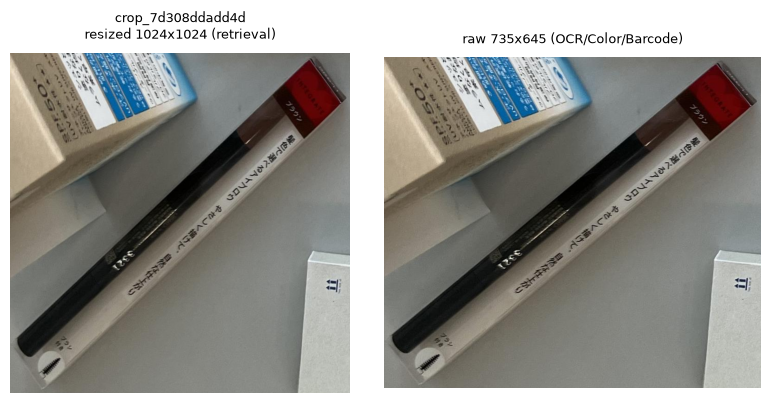

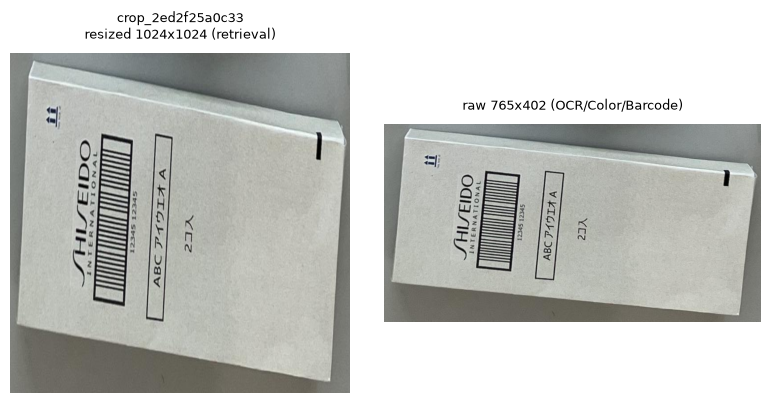

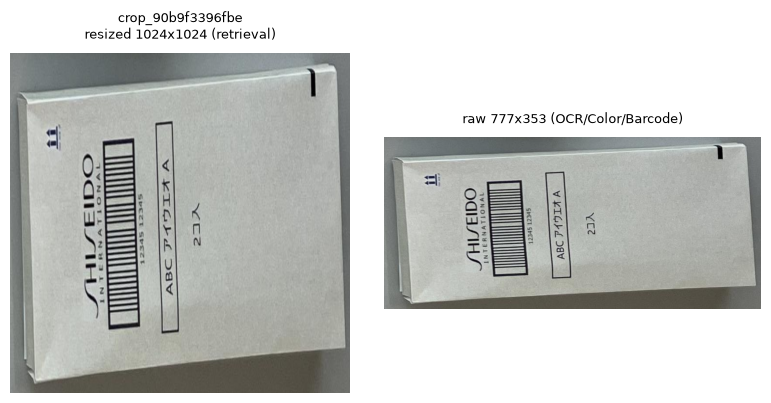

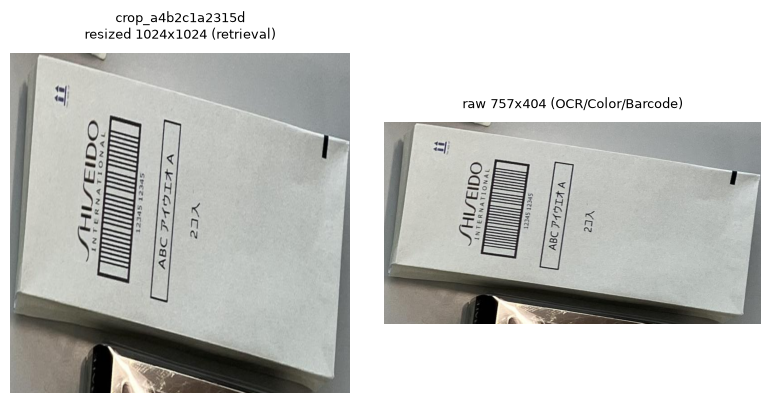

In [42]:
print(f"Tổng số crop: {len(crop_traces)}")

n_show = min(4, len(crop_traces))
for ct in crop_traces[:n_show]:
    crop = ct.crop
    show_images_row(
        [crop.image_array, crop.raw_image_array],
        titles=[
            f"{crop.crop_id}\nresized {crop.image_array.shape[1]}x{crop.image_array.shape[0]} (retrieval)",
            f"raw {crop.raw_image_array.shape[1]}x{crop.raw_image_array.shape[0]} (OCR/Color/Barcode)",
        ],
        figsize_per_img=(4, 4),
    )

## ⑤ Visual Retrieval (SigLIP2 + FAISS)

Ảnh mẫu gallery được lấy qua `retriever.get_product(product_id)["folder"]` — đúng field mà
`Retriever` dùng nội bộ để tra cứu catalog, nên đảm bảo khớp đúng cấu trúc `data/gallery/`.

In [ ]:
_retriever = pipeline._retriever  # dùng để trả về ảnh mẫu gallery cho mục đích minh họa
gallery_dir = config.resolve_path(config.paths.gallery_dir)

def _normalize_name(s: str) -> str:
    """Chuẩn hoá tên để so sánh: gộp mọi loại khoảng trắng/ký tự full-width
    (vd \u3000 vs space thường, （） vs ()) về cùng 1 dạng, rồi strip + lower.
    """
    s = unicodedata.normalize("NFKC", s)
    s = " ".join(s.split())  # gộp mọi whitespace liên tiếp thành 1 space thường
    return s.strip().lower()

# Cache toàn bộ tên thư mục thật trên đĩa 1 lần, tránh quét lại mỗi lần gọi
_gallery_folder_index = {
    _normalize_name(p.name): p
    for p in gallery_dir.iterdir()
    if p.is_dir()
}

def find_gallery_sample(product_id: str, n: int = 1):
    """Best-effort: tim anh mau trong data/gallery/ cho 1 product_id.

    So khop ten thu muc bang normalize (NFKC + gop whitespace) thay vi
    ghep path truc tiep, vi products.json va ten thu muc that tren dia
    co the lech nhau ve ky tu khoang trang (\u3000 vs space thuong) hoac
    dau ngoac full-width/half-width.
    """
    product = _retriever.get_product(str(product_id))
    folder_name = product.get("folder") if product else None

    folder = None
    if folder_name:
        folder = _gallery_folder_index.get(_normalize_name(folder_name))

    if folder is None:
        # fallback: thu tim thu muc trung ten voi product_id truc tiep
        folder = _gallery_folder_index.get(_normalize_name(str(product_id)))

    if folder is None:
        return []

    candidates = sorted(
        p for p in folder.iterdir()
        if p.suffix.lower() in (".jpg", ".jpeg", ".png")
    )

    images = []
    for p in candidates[:n]:
        img = cv2.imread(str(p))
        if img is not None:
            images.append(img)
    return images

### Chọn các case minh hoạ

Không cần ground truth vẫn có thể chọn được các case đại diện, dựa trên tín hiệu sẵn có trong trace:
similarity cao/thấp, case mà **rerank đã đổi kết quả** (dấu hiệu retrieval top-1 gốc có thể sai),
và case cần từng loại plugin (OCR / Color / Barcode).

In [44]:
def top1(rr):
    return rr.candidates[0] if rr.candidates else None

accepted_traces = [ct for ct in crop_traces if ct.final_decision.status != "rejected"]

examples = {}

if accepted_traces:
    examples["Similarity cao nhất"] = max(
        accepted_traces,
        key=lambda ct: top1(ct.retrieval_result).similarity_score if top1(ct.retrieval_result) else -1,
    )
    examples["Similarity thấp nhất (vẫn được chấp nhận)"] = min(
        accepted_traces,
        key=lambda ct: top1(ct.retrieval_result).similarity_score if top1(ct.retrieval_result) else 2,
    )

rerank_changed = [
    ct for ct in crop_traces
    if ct.plugin_result is not None and ct.decision_result.product_id != ct.final_decision.product_id
]
if rerank_changed:
    examples["Rerank thay đổi kết quả (retrieval top-1 có thể đã sai)"] = rerank_changed[0]

ocr_cases = [ct for ct in crop_traces if ct.plugin_result and "ocr" in ct.plugin_result.executed_plugins]
if ocr_cases:
    examples["Case cần OCR"] = ocr_cases[0]

color_cases = [ct for ct in crop_traces if ct.plugin_result and "color" in ct.plugin_result.executed_plugins]
if color_cases:
    examples["Case cần Color"] = color_cases[0]

barcode_cases = [ct for ct in crop_traces if ct.plugin_result and "barcode" in ct.plugin_result.executed_plugins]
if barcode_cases:
    examples["Case cần Barcode"] = barcode_cases[0]

print("Các case minh họa được chọn tự động:")
for name, ct in examples.items():
    print(f"  - {name}: {ct.crop.crop_id} (detection #{ct.crop.detection_index})")

Các case minh họa được chọn tự động:
  - Similarity cao nhất: crop_25a98bc915a1 (detection #6)
  - Similarity thấp nhất (vẫn được chấp nhận): crop_c86f0d9cd878 (detection #9)
  - Case cần OCR: crop_7d308ddadd4d (detection #0)
  - Case cần Color: crop_7d308ddadd4d (detection #0)
  - Case cần Barcode: crop_7d308ddadd4d (detection #0)


=== Similarity cao nhất ===


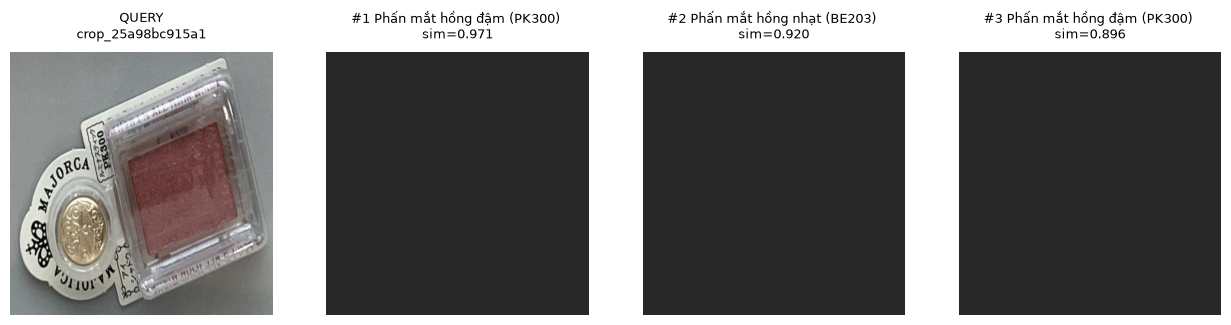

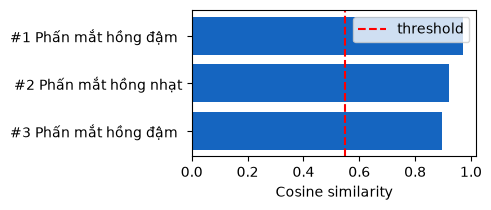

=== Similarity thấp nhất (vẫn được chấp nhận) ===


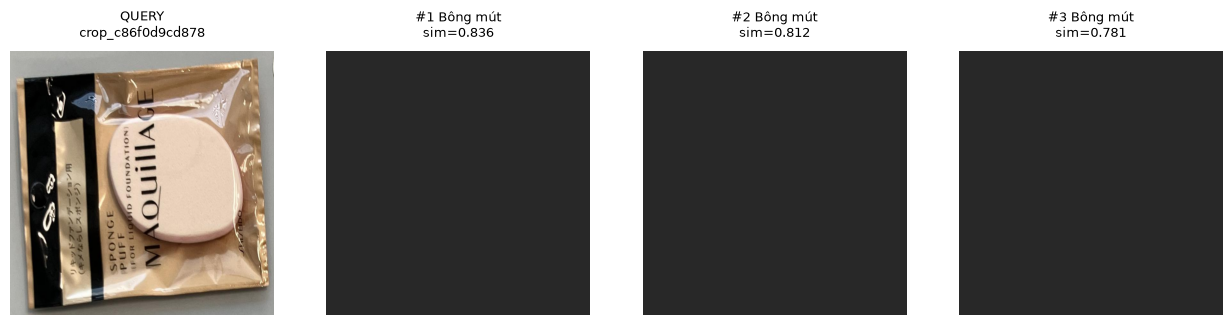

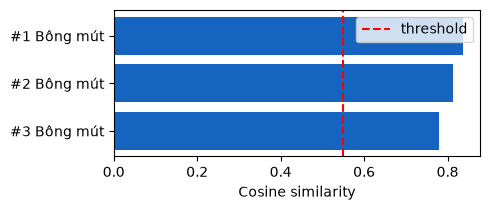

=== Case cần OCR ===


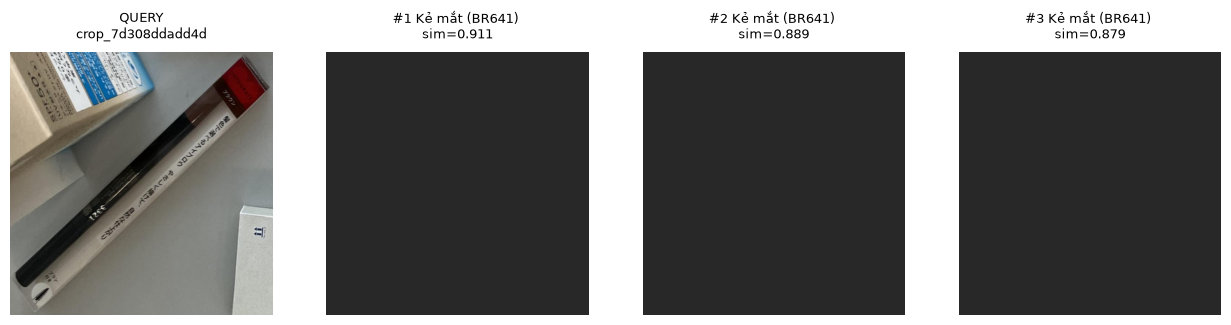

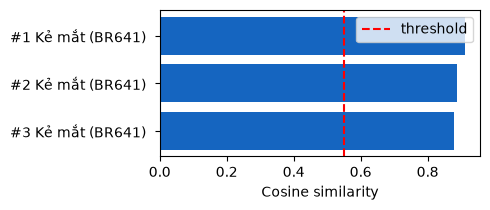

=== Case cần Color ===


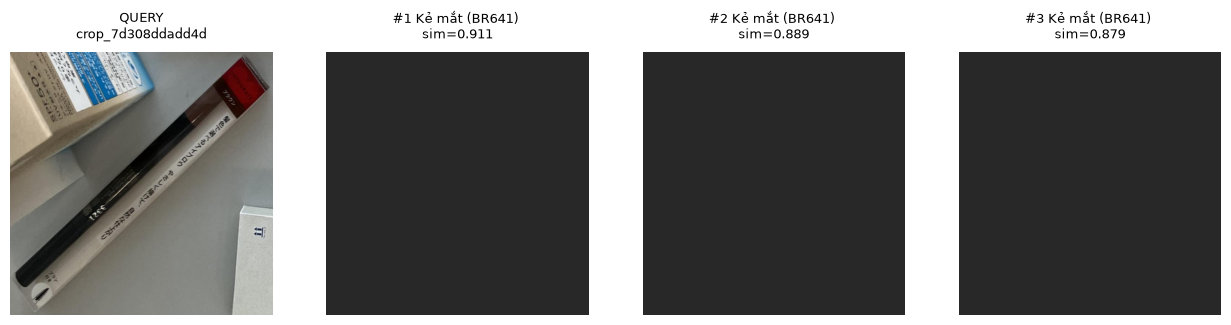

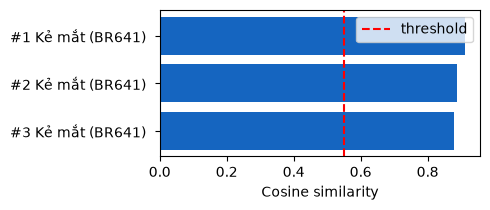

=== Case cần Barcode ===


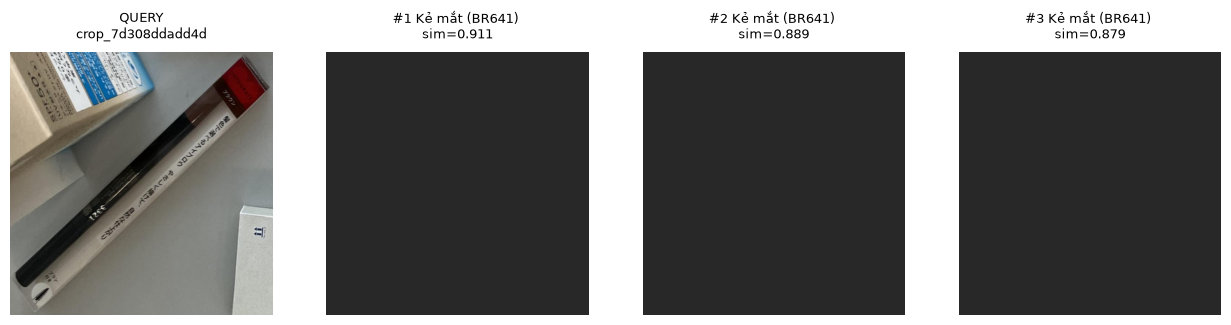

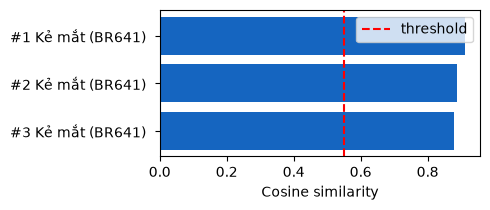

In [47]:
def visualize_retrieval(name, ct, top_k_show=3):
    crop = ct.crop
    rr = ct.retrieval_result
    candidates = rr.candidates[:top_k_show]

    query_img = crop.image_array
    gallery_imgs = [query_img]
    titles = [f"QUERY\n{crop.crop_id}"]

    for cand in candidates:
        samples = find_gallery_sample(cand.product_id, n=1)
        img = samples[0] if samples else np.full((200, 200, 3), 40, dtype=np.uint8)
        gallery_imgs.append(img)
        titles.append(f"#{cand.rank} {cand.product_name}\nsim={cand.similarity_score:.3f}")

    print(f"=== {name} ===")
    show_images_row(gallery_imgs, titles=titles, figsize_per_img=(3.2, 3.2))

    sims = [c.similarity_score for c in candidates]
    plt.figure(figsize=(5, 2.2))
    plt.barh([f"#{c.rank} {c.product_name[:18]}" for c in candidates][::-1], sims[::-1], color="#1565c0")
    plt.axvline(config.decision.similarity_threshold, color="red", linestyle="--", label="threshold")
    plt.xlabel("Cosine similarity")
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, ct in examples.items():
    visualize_retrieval(name, ct)

## ⑥ Decision Engine

In [48]:
rows = []
for ct in crop_traces:
    d = ct.decision_result
    rows.append({
        "crop_id": d.crop_id,
        "detection_idx": ct.crop.detection_index,
        "product_id": d.product_id,
        "product_name": d.product_name,
        "similarity": round(d.similarity_score, 3),
        "final_confidence": round(d.final_confidence, 3),
        "status": d.status,
        "needs_plugin": d.needs_plugin,
        "trigger_reasons": ", ".join(sorted(d.trigger_reasons)) if d.trigger_reasons else "",
        "forced_plugins": ", ".join(sorted(d.forced_plugins)) if d.forced_plugins else "",
    })

decision_df = pd.DataFrame(rows)

def _status_style(val):
    color = {"accepted": "#c8e6c9", "uncertain": "#ffe0b2", "rejected": "#ffcdd2"}.get(val, "")
    return f"background-color: {color}"

display(decision_df.style.map(_status_style, subset=["status"]))

,crop_id,detection_idx,product_id,product_name,similarity,final_confidence,status,needs_plugin,trigger_reasons,forced_plugins
0,crop_7d308ddadd4d,0,2,Kẻ mắt (BR641),0.911000,0.929000,accepted,True,ambiguous,
1,crop_2ed2f25a0c33,1,8,Kem ABC,0.949000,0.954000,accepted,True,"ambiguous, force",ocr
2,crop_90b9f3396fbe,2,8,Kem ABC,0.914000,0.930000,accepted,True,"ambiguous, force",ocr
3,crop_a4b2c1a2315d,3,8,Kem ABC,0.905000,0.923000,accepted,True,"ambiguous, force",ocr
4,crop_7e1a8f67af6a,4,8,Kem ABC,0.919000,0.931000,accepted,True,"ambiguous, force",ocr
5,crop_f19e40ac461c,5,1,Kem chống nắng,0.905000,0.922000,accepted,True,force,ocr
6,crop_25a98bc915a1,6,6,Phấn mắt hồng đậm (PK300),0.971000,0.963000,accepted,True,force,"barcode, color"
7,crop_30432794a4d1,7,3,Phấn má (OR210),0.873000,0.894000,accepted,True,ambiguous,
8,crop_3d86fa64c5ef,8,5,Phấn mắt hồng nhạt (BE203),0.953000,0.944000,accepted,True,"ambiguous, force","barcode, color"
9,crop_c86f0d9cd878,9,4,Bông mút,0.836000,0.825000,accepted,False,,


## ⑦ Plugin Evidence (OCR / Color / Barcode)

Hiển thị theo đúng cấu trúc `evidence` mà từng plugin trả về
(`src/plugins/ocr.py`, `color.py`, `barcode.py`).

Số crop có chạy plugin: 9 / 10

crop_7d308ddadd4d  |  plugin chạy: ['ocr', 'color', 'barcode']  |  1164.6 ms

[OCR] text=': 1 JoVAVoxedr 473^CM $ TZf1 crhtorm'  rotation=0  confidence=0.186  score=0.801  orientation_ambiguous=False


,text,confidence,quality,useful,text_type
0,:,0.374,0.020,False,other
1,1,0.174,0.020,False,numeric
2,JoVAVoxedr,0.386,1.000,True,alphabetic
3,473^CM $,0.099,0.512,True,mixed
4,TZf1,0.012,0.410,True,mixed
5,crhtorm,0.090,0.875,True,alphabetic



[Color] dominant_color=#69665a  representative_lab=[110.185, 127.985, 135.258]  roi_method=lower_center_fallback  roi_score=0.000


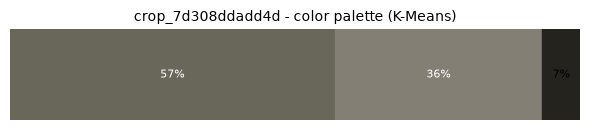


[Barcode] confidence=0.000  preprocessing_stage='none'
  (không giải mã được barcode nào)

crop_2ed2f25a0c33  |  plugin chạy: ['ocr']  |  3750.1 ms

[OCR] text='JHVEIDO INTERNATIONAL 12345 12345 ABC } IDIX A 23X'  rotation=90  confidence=0.596  score=0.931  orientation_ambiguous=True


,text,confidence,quality,useful,text_type
0,JHVEIDO,0.680,0.875,True,alphabetic
1,INTERNATIONAL,0.637,1.000,True,alphabetic
2,12345 12345,0.616,0.420,True,numeric
3,ABC } IDIX A,0.450,1.000,True,alphabetic
4,23X,0.669,0.307,True,mixed



crop_90b9f3396fbe  |  plugin chạy: ['ocr']  |  3198.8 ms

[OCR] text='JHUEIDO In TernationaL 12345 12345 ABC JAQIT A 2J7'  rotation=90  confidence=0.473  score=0.894  orientation_ambiguous=True


,text,confidence,quality,useful,text_type
0,JHUEIDO,0.717,0.875,True,alphabetic
1,In,0.477,0.150,False,alphabetic
2,TernationaL,0.105,1.000,True,alphabetic
3,12345 12345,0.622,0.420,True,numeric
4,ABC JAQIT A,0.572,1.000,True,alphabetic
5,2J7,0.449,0.307,True,mixed



crop_a4b2c1a2315d  |  plugin chạy: ['ocr']  |  3099.9 ms

[OCR] text='JHUEIDO nterna TIONAL 42345 ABC J(OIX A 2JX'  rotation=90  confidence=0.699  score=0.924  orientation_ambiguous=True


...


crop_7e1a8f67af6a  |  plugin chạy: ['ocr']  |  2977.9 ms

[OCR] text='JHUEIDO Tiomal 1845 2JA 12345 JADIX A ABC'  rotation=90  confidence=0.596  score=0.913  orientation_ambiguous=True


,text,confidence,quality,useful,text_type
0,JHUEIDO,0.862,0.875,True,alphabetic
1,Tiomal,0.280,0.750,True,alphabetic
2,1845,0.340,0.210,True,numeric
3,2JA,0.686,0.307,True,mixed
4,12345,0.645,0.263,True,numeric
5,JADIX A,0.416,0.750,True,alphabetic
6,ABC,1.000,0.375,True,alphabetic



crop_f19e40ac461c  |  plugin chạy: ['ocr']  |  2808.0 ms

[OCR] text='Np N 04 0 1 3+77X7l- SPRAY 73~+ SKINCARE ANESSA "-JI71Uv SUNSCREEN 609 PERFECT'  rotation=270  confidence=0.743  score=0.876  orientation_ambiguous=True


,text,confidence,quality,useful,text_type
0,Np,0.392,0.150,False,alphabetic
1,N,0.126,0.020,False,alphabetic
2,04,0.379,0.150,False,numeric
3,0,0.351,0.020,False,numeric
4,1,0.291,0.020,False,numeric
5,0,0.226,0.020,False,numeric
6,3+77X7l-,0.102,0.615,True,mixed
7,SPRAY,0.750,0.625,True,alphabetic
8,73~+,0.129,0.150,False,numeric
9,SKINCARE,0.993,1.000,True,alphabetic



crop_25a98bc915a1  |  plugin chạy: ['color', 'barcode']  |  308.2 ms

[Color] dominant_color=#735956  representative_lab=[103.938, 138.001, 134.031]  roi_method=lower_center_fallback  roi_score=0.000


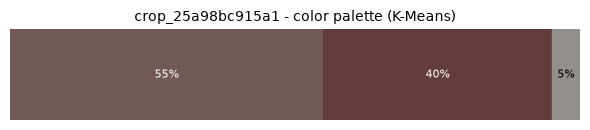


[Barcode] confidence=0.000  preprocessing_stage='none'
  (không giải mã được barcode nào)

crop_30432794a4d1  |  plugin chạy: ['ocr', 'color', 'barcode']  |  2942.3 ms

[OCR] text='laol J9j) RAC JM< a4 Sk of brillicny 5s*e'  rotation=90  confidence=0.200  score=0.851  orientation_ambiguous=True


,text,confidence,quality,useful,text_type
0,laol,0.697,0.500,True,alphabetic
1,J9j),0.020,0.307,True,mixed
2,RAC JM< a4,0.025,0.717,True,mixed
3,Sk,0.028,0.150,False,alphabetic
4,of brillicny,0.101,1.000,True,alphabetic
5,5s*e,0.304,0.307,True,mixed



[Color] dominant_color=#7c5444  representative_lab=[101.204, 143.809, 144.035]  roi_method=lower_center_fallback  roi_score=0.000


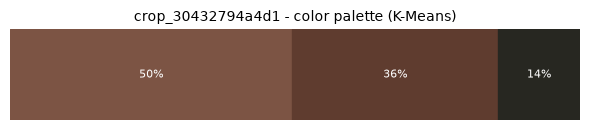


[Barcode] confidence=0.000  preprocessing_stage='none'
  (không giải mã được barcode nào)

crop_3d86fa64c5ef  |  plugin chạy: ['color', 'barcode']  |  292.5 ms

[Color] dominant_color=#bea79d  representative_lab=[179.165, 135.947, 136.431]  roi_method=lower_center_fallback  roi_score=0.000


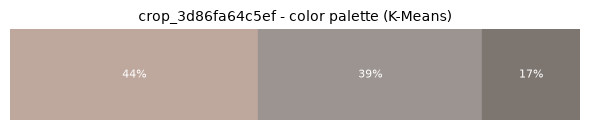


[Barcode] confidence=0.000  preprocessing_stage='none'
  (không giải mã được barcode nào)


In [49]:
plugin_traces = [ct for ct in crop_traces if ct.plugin_result is not None]
print(f"Số crop có chạy plugin: {len(plugin_traces)} / {len(crop_traces)}")

for ct in plugin_traces:
    pr = ct.plugin_result
    print(f"\n{'=' * 70}")
    print(f"{pr.crop_id}  |  plugin chạy: {pr.executed_plugins}  |  {pr.processing_time_ms:.1f} ms")

    # --- OCR ---
    if "ocr" in pr.evidence:
        ev = pr.evidence["ocr"]
        print(f"\n[OCR] text='{ev.get('text', '')}'  rotation={ev.get('rotation')}  "
              f"confidence={ev.get('confidence', 0):.3f}  score={ev.get('score', 0):.3f}  "
              f"orientation_ambiguous={ev.get('orientation_ambiguous')}")
        fragments = ev.get("fragments", [])
        if fragments:
            frag_df = pd.DataFrame([
                {
                    "text": f.get("text", ""),
                    "confidence": round(f.get("confidence", 0), 3),
                    "quality": round(f.get("quality", 0), 3),
                    "useful": f.get("useful", False),
                    "text_type": f.get("text_type", ""),
                }
                for f in fragments
            ])
            display(frag_df)
        else:
            print("  (không có fragment nào được phát hiện)")

    # --- Color ---
    if "color" in pr.evidence:
        ev = pr.evidence["color"]
        print(f"\n[Color] dominant_color={ev.get('dominant_color')}  "
              f"representative_lab={ev.get('representative_lab')}  "
              f"roi_method={ev.get('roi', {}).get('method')}  "
              f"roi_score={ev.get('roi', {}).get('score', 0):.3f}")
        palette = ev.get("palette", [])
        percentages = ev.get("percentages", [])
        if palette:
            show_color_palette(palette, percentages, title=f"{pr.crop_id} - color palette (K-Means)")

    # --- Barcode ---
    if "barcode" in pr.evidence:
        ev = pr.evidence["barcode"]
        print(f"\n[Barcode] confidence={ev.get('confidence', 0):.3f}  "
              f"preprocessing_stage='{ev.get('preprocessing_stage')}'")
        barcodes = ev.get("barcodes", [])
        if barcodes:
            display(pd.DataFrame(barcodes))
        else:
            print("  (không giải mã được barcode nào)")

## ⑧ Reranking & Fusion — Trước / Sau

`Reranker.rerank()` gắn thêm `rerank_debug` (rank_before, rank_after, breakdown điểm số
base/barcode/ocr/color cho từng ứng viên) vào `DecisionResult` cuối cùng — notebook dùng
trực tiếp thông tin này thay vì tự suy luận lại.

In [50]:
rows = []
for ct in crop_traces:
    if ct.plugin_result is None:
        continue
    before, after = ct.decision_result, ct.final_decision
    debug = getattr(after, "rerank_debug", None) or {}
    guard = debug.get("retrieval_guard", {})
    rows.append({
        "crop_id": before.crop_id,
        "product_id_before": before.product_id,
        "product_id_after": after.product_id,
        "changed": before.product_id != after.product_id,
        "confidence_before": round(before.final_confidence, 3),
        "confidence_after": round(after.final_confidence, 3),
        "status_before": before.status,
        "status_after": after.status,
        "switch_reverted": debug.get("switch_reverted"),
        "confusable_conflict": debug.get("confusable_conflict_detected"),
        "consensus_winner": guard.get("consensus_winner"),
        "rerank_latency_ms": round(after.rerank_latency_ms, 2),
    })

rerank_df = pd.DataFrame(rows)
if not rerank_df.empty:
    display(rerank_df.style.apply(
        lambda r: ["background-color: #fff59d" if r["changed"] else "" for _ in r], axis=1
    ))
    print(f"So case bi thay doi ket qua boi rerank: {rerank_df['changed'].sum()} / {len(rerank_df)}")
else:
    print("Khong co crop nao chay plugin -> khong co gi de rerank.")

,crop_id,product_id_before,product_id_after,changed,confidence_before,confidence_after,status_before,status_after,switch_reverted,confusable_conflict,consensus_winner,rerank_latency_ms
0,crop_7d308ddadd4d,2,2,False,0.929000,0.929000,accepted,accepted,False,False,2,0.720000
1,crop_2ed2f25a0c33,8,8,False,0.954000,1.000000,accepted,accepted,False,False,8,1.170000
2,crop_90b9f3396fbe,8,8,False,0.930000,1.000000,accepted,accepted,False,False,8,0.860000
3,crop_a4b2c1a2315d,8,8,False,0.923000,1.000000,accepted,accepted,False,False,8,0.950000
4,crop_7e1a8f67af6a,8,8,False,0.931000,1.000000,accepted,accepted,False,False,8,0.770000
5,crop_f19e40ac461c,1,1,False,0.922000,0.922000,accepted,accepted,False,False,1,4.010000
6,crop_25a98bc915a1,6,6,False,0.963000,0.963000,accepted,accepted,False,False,6,0.540000
7,crop_30432794a4d1,3,3,False,0.894000,0.894000,accepted,accepted,False,False,3,1.110000
8,crop_3d86fa64c5ef,5,5,False,0.944000,0.944000,accepted,accepted,False,False,5,0.450000


So case bi thay doi ket qua boi rerank: 0 / 9


### Chi tiết điểm số từng ứng viên (base vs sau fusion) — cho 1 case cụ thể

In [51]:
rows = []
for ct in crop_traces:
    if ct.plugin_result is None:
        continue
    before, after = ct.decision_result, ct.final_decision
    debug = getattr(after, "rerank_debug", None) or {}
    guard = debug.get("retrieval_guard", {})
    rows.append({
        "crop_id": before.crop_id,
        "product_id_before": before.product_id,
        "product_id_after": after.product_id,
        "changed": before.product_id != after.product_id,
        "confidence_before": round(before.final_confidence, 3),
        "confidence_after": round(after.final_confidence, 3),
        "status_before": before.status,
        "status_after": after.status,
        "switch_reverted": debug.get("switch_reverted"),
        "confusable_conflict": debug.get("confusable_conflict_detected"),
        "consensus_winner": guard.get("consensus_winner"),
        "rerank_latency_ms": round(after.rerank_latency_ms, 2),
    })

rerank_df = pd.DataFrame(rows)
if not rerank_df.empty:
    display(rerank_df.style.apply(
        lambda r: ["background-color: #fff59d" if r["changed"] else "" for _ in r], axis=1
    ))
    print(f"Số case bị thay đổi kết quả bởi rerank: {rerank_df['changed'].sum()} / {len(rerank_df)}")
else:
    print("Không có crop nào chạy plugin -> không có gì để rerank.")

,crop_id,product_id_before,product_id_after,changed,confidence_before,confidence_after,status_before,status_after,switch_reverted,confusable_conflict,consensus_winner,rerank_latency_ms
0,crop_7d308ddadd4d,2,2,False,0.929000,0.929000,accepted,accepted,False,False,2,0.720000
1,crop_2ed2f25a0c33,8,8,False,0.954000,1.000000,accepted,accepted,False,False,8,1.170000
2,crop_90b9f3396fbe,8,8,False,0.930000,1.000000,accepted,accepted,False,False,8,0.860000
3,crop_a4b2c1a2315d,8,8,False,0.923000,1.000000,accepted,accepted,False,False,8,0.950000
4,crop_7e1a8f67af6a,8,8,False,0.931000,1.000000,accepted,accepted,False,False,8,0.770000
5,crop_f19e40ac461c,1,1,False,0.922000,0.922000,accepted,accepted,False,False,1,4.010000
6,crop_25a98bc915a1,6,6,False,0.963000,0.963000,accepted,accepted,False,False,6,0.540000
7,crop_30432794a4d1,3,3,False,0.894000,0.894000,accepted,accepted,False,False,3,1.110000
8,crop_3d86fa64c5ef,5,5,False,0.944000,0.944000,accepted,accepted,False,False,5,0.450000


Số case bị thay đổi kết quả bởi rerank: 0 / 9


## E2E Summary

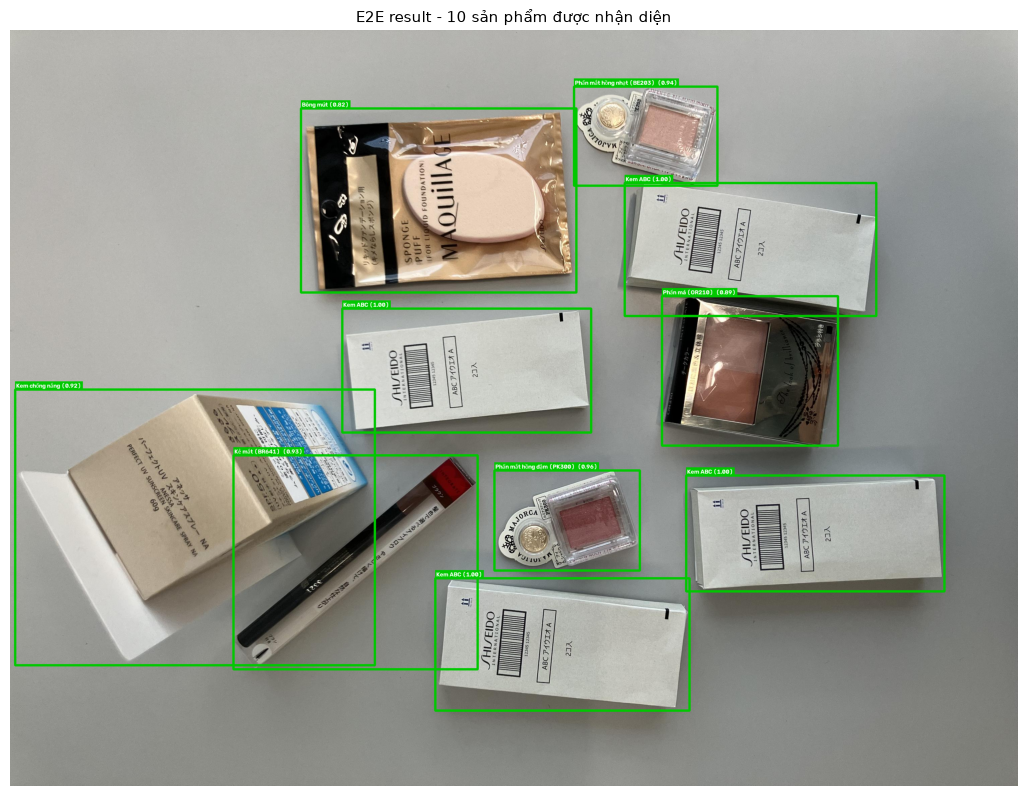

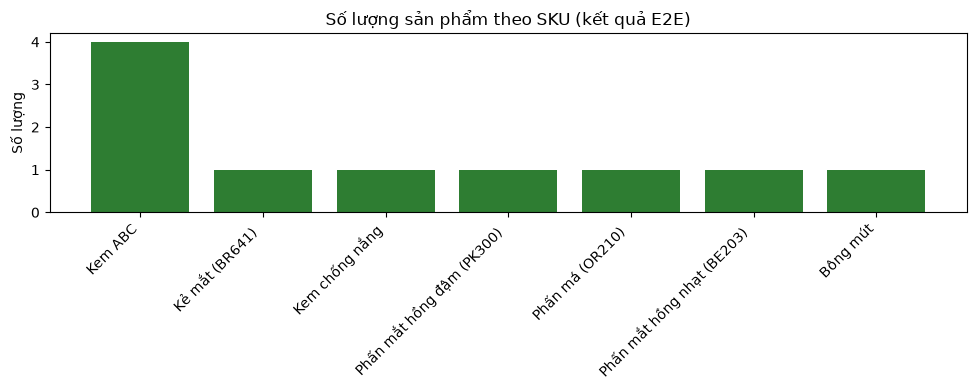


Tổng thời gian pipeline: 22704.8 ms
Tổng số sản phẩm được đếm: 10


In [52]:
box_thickness = config.storage.box_thickness

boxes_final, labels_final, colors_final = [], [], []
for ct in crop_traces:
    fd = ct.final_decision
    if fd.status == "rejected" or fd.product_id is None:
        continue
    boxes_final.append(ct.crop.source_bbox)
    labels_final.append(f"{fd.product_name} ({fd.final_confidence:.2f})")
    colors_final.append(STATUS_COLORS_BGR.get(fd.status, (0, 200, 0)))

final_vis = draw_detections(raw_bgr, boxes_final, labels=labels_final, colors=colors_final,
                            thickness=box_thickness, font_scale=0.6)
show_image(final_vis, title=f"E2E result - {len(boxes_final)} sản phẩm được nhận diện", figsize=(13, 10))
plt.show()

counts = Counter(ct.final_decision.product_name for ct in crop_traces if ct.final_decision.status != "rejected")
if counts:
    names, values = zip(*sorted(counts.items(), key=lambda x: -x[1]))
    plt.figure(figsize=(10, 4))
    plt.bar(names, values, color="#2e7d32")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Số lượng")
    plt.title("Số lượng sản phẩm theo SKU (kết quả E2E)")
    plt.tight_layout()
    plt.show()

print(f"\nTổng thời gian pipeline: {result.processing_time_ms:.1f} ms")
print(f"Tổng số sản phẩm được đếm: {result.total_items}")

## (Tùy chọn) So sánh với Ground Truth từ Benchmark COCO

Chỉ chạy phần này nếu ảnh query bạn chọn ở mục 3 **cũng nằm trong** `data/benchmark/images/` và có
annotation trong `data/benchmark/_annotations.coco.json`. Khi đó notebook sẽ match từng detection với
ground-truth box (theo IoU, dùng `BoundingBox.iou()`) để biết chính xác case nào retrieval "đúng" / "sai",
thay vì chỉ suy luận gián tiếp như ở mục ⑤.

In [53]:
USE_GROUND_TRUTH_FROM_BENCHMARK = False  # đổi thành True nếu ảnh query nằm trong benchmark

if USE_GROUND_TRUTH_FROM_BENCHMARK:
    coco_path = config.resolve_path(config.paths.benchmark_labels_dir)
    with open(coco_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    image_entry = next(
        (im for im in coco["images"] if Path(im["file_name"]).stem == image_data.image_id), None
    )
    if image_entry is None:
        print(f"Không tìm thấy '{image_data.image_id}' trong benchmark COCO annotations.")
    else:
        gt_anns = [a for a in coco["annotations"] if a["image_id"] == image_entry["id"]]

        def gt_box_to_bbox(ann):
            x, y, bw, bh = ann["bbox"]
            return BoundingBox(x1=x, y1=y, x2=x + bw, y2=y + bh)

        gt_matches = {}
        for i, det in enumerate(detections):
            best_iou, best_ann = 0.0, None
            for ann in gt_anns:
                iou = det.bbox.iou(gt_box_to_bbox(ann))
                if iou > best_iou:
                    best_iou, best_ann = iou, ann
            if best_ann is not None and best_iou >= config.validation.iou_match_threshold:
                gt_matches[i] = {
                    "gt_product_id": str(best_ann["category_id"]),
                    "iou": round(best_iou, 3),
                }

        print(f"Match được {len(gt_matches)}/{len(detections)} detection với ground truth "
              f"(IoU >= {config.validation.iou_match_threshold}).")

        eval_rows = []
        for ct in crop_traces:
            idx = ct.crop.detection_index
            gt = gt_matches.get(idx)
            pred_id = ct.final_decision.product_id
            eval_rows.append({
                "crop_id": ct.crop.crop_id,
                "detection_idx": idx,
                "gt_product_id": gt["gt_product_id"] if gt else None,
                "pred_product_id": pred_id,
                "correct": (gt is not None and gt["gt_product_id"] == pred_id),
                "matched_iou": gt["iou"] if gt else None,
            })

        eval_df = pd.DataFrame(eval_rows)
        display(eval_df)
        matched = eval_df.dropna(subset=["gt_product_id"])
        if len(matched) > 0:
            acc = matched["correct"].mean()
            print(f"Accuracy trên các detection match được GT: {acc:.1%} "
                  f"({matched['correct'].sum()}/{len(matched)})")

## Ghi chú

- Notebook gọi trực tiếp `InventoryPipeline.run_with_trace()` — đúng pipeline production, không có
  logic song song/giả lập nào khác.
- Ảnh gallery minh hoạ dùng `retriever.get_product(product_id)["folder"]` (truy cập nội bộ
  `pipeline._retriever` chỉ để lấy metadata hiển thị — không phải API chính thức, chỉ dùng cho mục
  đích trực quan hoá trong notebook này).
- Mục ⑤ chọn case minh hoạ **không cần ground truth**: dựa vào similarity cao/thấp nhất và case mà
  rerank đã đổi kết quả (dấu hiệu gián tiếp cho retrieval sai ở top-1). Nếu ảnh query nằm trong
  `data/benchmark/`, dùng mục cuối (GT COCO) để có đánh giá đúng/sai chính xác.
- Nếu đổi `QUERY_IMAGE_PATH` ở mục 3 và chạy lại toàn bộ notebook, mọi phần phía dưới sẽ tự cập nhật.